# Neural Networks: Best Practices, End-to-End (PyTorch)

A from-scratch tour of how to run a neural-network **experiment** properly — for
both **regression** and **classification** — using PyTorch and real scikit-learn
datasets.

By the end you should be able to take *any* tabular dataset and stand up a
correct, reproducible NN experiment yourself: data → splits → scaling → tensors →
model → loss → training loop → evaluation → diagnostics.

> Run order matters — execute cells top to bottom. Each code cell builds on the
> previous one.

## 0. What actually *is* a neural-network experiment?

A "neural network" is just a stack of linear maps (`y = Wx + b`) separated by
non-linear **activation** functions. Training = repeatedly nudging the weights
`W, b` to reduce a **loss** (how wrong the predictions are), using gradients
computed by **backpropagation**.

That model is a small part of the job. A *trustworthy experiment* is the real
skill, and it's the same checklist every time:

| Step | Why it matters |
|------|----------------|
| **Reproducibility** (seeds, device) | So results are comparable run-to-run. |
| **Train / validation / test split** | Validation tunes choices; test is the *untouched* final judge. |
| **Feature scaling (fit on train only)** | NNs train far better on standardized inputs; fitting on all data **leaks** test info. |
| **Batching (DataLoader)** | Mini-batches give faster, more stable gradient updates. |
| **Model definition** | Layers, widths, activations, output shape suited to the task. |
| **Loss + optimizer** | The thing you minimize, and the rule for updating weights. |
| **Training loop** | forward → loss → backward → step, with `train()`/`eval()` modes. |
| **Evaluation on test** | Task-appropriate metrics, in original units. |
| **Diagnostics** | Loss curves + prediction plots to spot under/over-fitting. |

We'll do this twice — once for regression, once for classification — and you'll
see that **only a few pieces change** between the two.

## 0.1 PyTorch or TensorFlow/Keras?

Both are excellent. The honest summary:

- **PyTorch** — define-by-run (the network executes like normal Python), explicit
  training loops *you* write. This makes the mechanics visible, which is why it
  dominates research/quant and why we use it here. You learn *what* is happening.
- **TensorFlow / Keras** — higher-level. `model.compile(...)` + `model.fit(...)`
  hides the loop. Less boilerplate, great for standard production pipelines, but
  it hides exactly the parts a learner needs to see.

**Best-practice rule of thumb:** learn the explicit PyTorch loop first (you'll
understand every other framework afterwards). Reach for Keras when you want speed
of delivery on a conventional model and don't need a custom training step.

Everything below is framework-agnostic in *concept* — the checklist is identical
in Keras; only the syntax differs.

## 1. Setup & reproducibility

First cell of *every* experiment: imports, seeds, and device selection.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score, roc_curve

import matplotlib.pyplot as plt

# Reproducibility: seed every source of randomness we touch.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Use a GPU if one exists, else CPU. Tensors/models get sent to this device.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("PyTorch:", torch.__version__)

Using device: cpu
PyTorch: 2.12.0+cpu


**What this means**

- **Seeds** make weight initialization, shuffling, and dropout deterministic, so
  two runs are comparable. Without them you can't tell if a change helped or you
  just got lucky.
- **`device`** is where computation happens. Writing `.to(device)` everywhere
  means the *same* notebook runs on CPU or GPU unchanged.

## 2. Regression experiment — California Housing

**Task:** predict the median house value (a continuous number) for a district
from 8 features (income, house age, rooms, location, ...).

This is **regression**: the output is a real number, so we'll measure error with
RMSE and R².

### 2.1 Load & inspect the data

In [2]:
housing = fetch_california_housing()
X, y = housing.data, housing.target          # X: (20640, 8), y: median value in $100k
print("Features:", housing.feature_names)
print("X shape:", X.shape, "| y shape:", y.shape)
print("Target range: %.2f to %.2f (units of $100,000)" % (y.min(), y.max()))

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X shape: (20640, 8) | y shape: (20640,)
Target range: 0.15 to 5.00 (units of $100,000)


**What this means** — `X` is a 2-D array `(samples, features)`; `y` is a 1-D
array of targets. Always look at shapes and target range *before* modelling —
it tells you the output layer size (1 here) and roughly what scale your
predictions should land in.

### 2.2 Split into train / validation / test

Three sets, not two:
- **train** — the model learns weights here.
- **validation** — you check this during training to tune choices (architecture,
  epochs, learning rate). The model never trains on it.
- **test** — touched **once**, at the very end, as an honest estimate of
  real-world performance.

In [3]:
# First carve off the test set (20%), then split the rest into train/val.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED)   # 0.2 of the remaining 80%

print("train:", X_train.shape[0], "| val:", X_val.shape[0], "| test:", X_test.shape[0])

train: 13209 | val: 3303 | test: 4128


**What this means** — if you tune your model by peeking at the test set, the
test score stops being an unbiased estimate (you've implicitly fit to it). The
validation set absorbs that tuning so the test set stays clean.

### 2.3 Scale features — fit on **train only**

Neural nets train much better when inputs are standardized (mean 0, std 1):
gradients are better behaved and learning is faster. The critical rule: compute
the scaling statistics on the **training set only**, then apply them to val/test.

In [4]:
# Scale inputs. Fit (learn mean/std) on TRAIN, then transform all three sets.
x_scaler = StandardScaler().fit(X_train)
X_train_s = x_scaler.transform(X_train)
X_val_s   = x_scaler.transform(X_val)
X_test_s  = x_scaler.transform(X_test)

# For regression it also helps to scale the TARGET. We'll invert this later
# so final metrics are reported in real ($100k) units.
y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
y_train_s = y_scaler.transform(y_train.reshape(-1, 1))
y_val_s   = y_scaler.transform(y_val.reshape(-1, 1))
print("Scaled train mean ~0:", X_train_s.mean(axis=0).round(2))

Scaled train mean ~0: [-0. -0.  0. -0.  0.  0.  0. -0.]


**What this means — data leakage.** If you fit the scaler on *all* the data,
information about the test set (its mean/spread) leaks into training, and your
test score becomes optimistic. Fitting on train only mirrors reality: at
deployment you won't have seen future data.

### 2.4 Convert to tensors and wrap in DataLoaders

PyTorch works with `Tensor`s. A `DataLoader` serves the data in shuffled
**mini-batches** during training.

In [5]:
def to_tensor(a):
    return torch.tensor(a, dtype=torch.float32)

train_ds = TensorDataset(to_tensor(X_train_s), to_tensor(y_train_s))
val_ds   = TensorDataset(to_tensor(X_val_s),   to_tensor(y_val_s))

# shuffle=True for training (decorrelates batches); False for evaluation.
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

xb, yb = next(iter(train_loader))
print("one batch:", xb.shape, yb.shape)   # (64, 8) (64, 1)

one batch: torch.Size([64, 8]) torch.Size([64, 1])


**What this means** — instead of computing the gradient on all 13k rows at
once, we update on small batches of 64. This is **mini-batch gradient descent**:
faster, fits in memory, and the noise actually helps generalization. Targets are
shaped `(batch, 1)` to match the model's output.

### 2.5 Define the model

A small **multilayer perceptron (MLP)**: two hidden layers with ReLU activations,
and a single output neuron (because we predict one number).

In [6]:
reg_model = nn.Sequential(
    nn.Linear(8, 64),   # input: 8 features -> 64 hidden units
    nn.ReLU(),          # non-linearity; without it the whole net collapses to one linear map
    nn.Linear(64, 64),
    nn.ReLU(),
    nn.Linear(64, 1),   # output: 1 number (regression). NO activation here.
).to(device)

print(reg_model)
n_params = sum(p.numel() for p in reg_model.parameters())
print("trainable parameters:", n_params)

Sequential(
  (0): Linear(in_features=8, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
)
trainable parameters: 4801


**What this means**

- **`nn.Linear(in, out)`** is a fully-connected layer: `out = W·in + b`.
- **`nn.ReLU`** = `max(0, x)`. The non-linearity is what lets the network model
  curves; stack only linear layers and you'd have a single linear model.
- **Output layer has no activation** for regression — we want any real number.
  (For classification we'll change this, see §3.)

### 2.6 Loss function & optimizer

In [7]:
reg_loss_fn = nn.MSELoss()                                   # mean squared error: standard for regression
reg_optimizer = torch.optim.Adam(reg_model.parameters(), lr=1e-3)  # Adam: robust default optimizer

**What this means**

- **Loss** quantifies wrongness. **MSE** penalizes large errors quadratically —
  the natural choice for continuous targets.
- **Optimizer** is the rule for updating weights from gradients. **Adam** adapts
  the step size per parameter and is a strong, low-fuss default. **`lr`**
  (learning rate) is the single most important knob: too high diverges, too low
  crawls.

### 2.7 The training loop (the heart of it)

We define it **once** as a reusable function and walk through every line below —
then reuse it for classification unchanged.

In [8]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer, epochs):
    history = {"train": [], "val": []}
    for epoch in range(epochs):
        # ---- TRAIN PASS ----
        model.train()                     # enable train-mode behaviour (dropout/batchnorm)
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()         # clear gradients from previous step
            pred = model(xb)              # forward pass
            loss = loss_fn(pred, yb)      # how wrong are we?
            loss.backward()               # backprop: compute gradients
            optimizer.step()              # update weights
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        # ---- VALIDATION PASS (no weight updates) ----
        model.eval()                      # eval-mode behaviour
        vrunning = 0.0
        with torch.no_grad():             # don't track gradients -> faster, less memory
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                vrunning += loss_fn(model(xb), yb).item() * xb.size(0)
        val_loss = vrunning / len(val_loader.dataset)

        history["train"].append(train_loss)
        history["val"].append(val_loss)
        if (epoch + 1) % max(1, epochs // 10) == 0:
            print(f"epoch {epoch+1:3d} | train {train_loss:.4f} | val {val_loss:.4f}")
    return history

**What each line means** — this is the loop you must know cold:

1. **`model.train()` / `model.eval()`** — toggle layers that behave differently in
   training vs inference (dropout, batchnorm). Harmless here but essential habit.
2. **`optimizer.zero_grad()`** — PyTorch *accumulates* gradients; you must clear
   them each step or they'd sum across batches.
3. **`pred = model(xb)`** — the **forward pass**.
4. **`loss = loss_fn(pred, yb)`** — compare prediction to truth.
5. **`loss.backward()`** — **backpropagation**: autograd computes the gradient of
   the loss w.r.t. every weight.
6. **`optimizer.step()`** — nudge each weight downhill along its gradient.
7. **`torch.no_grad()`** in validation — we're only measuring, not learning, so
   skip gradient bookkeeping.

One full pass over the training data is an **epoch**.

In [9]:
reg_history = train_model(reg_model, train_loader, val_loader,
                          reg_loss_fn, reg_optimizer, epochs=40)

epoch   4 | train 0.2624 | val 0.3326


epoch   8 | train 0.2447 | val 0.3634


epoch  12 | train 0.2218 | val 0.2549


epoch  16 | train 0.2119 | val 0.2372


epoch  20 | train 0.2056 | val 0.2483


epoch  24 | train 0.2103 | val 0.2251


epoch  28 | train 0.1997 | val 0.2260


epoch  32 | train 0.1989 | val 0.2425


epoch  36 | train 0.1924 | val 0.2206


epoch  40 | train 0.1928 | val 0.2233


### 2.8 Evaluate on the untouched test set

We report metrics in **original units** by inverting the target scaling.

In [10]:
reg_model.eval()
with torch.no_grad():
    pred_s = reg_model(to_tensor(X_test_s).to(device)).cpu().numpy()

# Invert the target scaling so errors are in $100k units.
pred = y_scaler.inverse_transform(pred_s).ravel()

rmse = mean_squared_error(y_test, pred) ** 0.5
r2 = r2_score(y_test, pred)
print(f"Test RMSE: {rmse:.3f}  (i.e. ~${rmse*100_000:,.0f} typical error)")
print(f"Test R^2 : {r2:.3f}  (1.0 = perfect, 0 = no better than predicting the mean)")

Test RMSE: 0.531  (i.e. ~$53,147 typical error)
Test R^2 : 0.784  (1.0 = perfect, 0 = no better than predicting the mean)


**What this means** — **RMSE** is the typical prediction error in the target's
own units. **R²** is the fraction of variance explained (closer to 1 is better).
Reporting in original units (not the scaled space) is what makes the number
*interpretable* to a stakeholder.

### 2.9 Diagnostics — loss curve & predicted-vs-actual

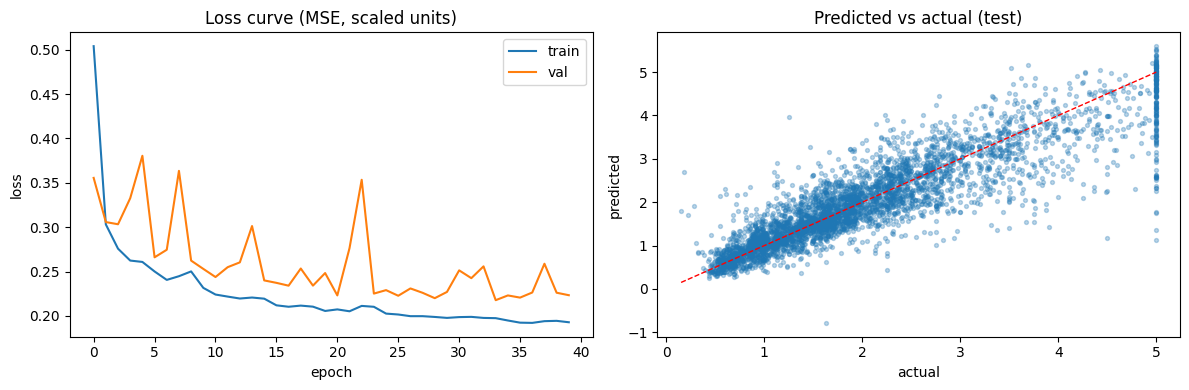

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(reg_history["train"], label="train")
ax[0].plot(reg_history["val"], label="val")
ax[0].set_title("Loss curve (MSE, scaled units)")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend()

ax[1].scatter(y_test, pred, s=8, alpha=0.3)
lims = [y_test.min(), y_test.max()]
ax[1].plot(lims, lims, "r--", lw=1)        # perfect-prediction line
ax[1].set_title("Predicted vs actual (test)")
ax[1].set_xlabel("actual"); ax[1].set_ylabel("predicted")
plt.tight_layout(); plt.show()

**How to read these**

- **Loss curve:** both lines should fall and flatten. If **val** turns *up* while
  **train** keeps falling → **overfitting** (train longer ≠ better; add
  regularization or stop earlier). If both stay high → **underfitting** (bigger
  model / more epochs / higher lr).
- **Predicted vs actual:** points hugging the red diagonal = good. Systematic
  curvature or a ceiling (note the cap at 5.0 here, an artifact of the dataset)
  reveals where the model struggles.

## 3. Classification experiment — Breast Cancer

**Task:** predict whether a tumour is malignant or benign (a **binary class**)
from 30 cell-nucleus measurements.

The whole pipeline is the **same** as regression. Watch for the *only four
things that change*:

| Piece | Regression | Classification (binary) |
|-------|-----------|--------------------------|
| Target dtype | float value | 0/1 label |
| Output layer | 1 unit, no activation | 1 **logit**, no activation (sigmoid lives in the loss) |
| Loss | `MSELoss` | `BCEWithLogitsLoss` |
| Metrics | RMSE, R² | accuracy, ROC AUC |

Everything else — splits, scaling, DataLoaders, the `train_model` function — is
reused verbatim.

### 3.1 Load, split, scale

Note: we scale the **features** but **not** the target (labels are already 0/1).

In [12]:
cancer = load_breast_cancer()
Xc, yc = cancer.data, cancer.target          # Xc: (569, 30), yc: 0=malignant, 1=benign
print("X shape:", Xc.shape, "| classes:", np.bincount(yc), "(malignant, benign)")

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.2, random_state=SEED, stratify=yc)   # stratify keeps class ratio
Xc_tr, Xc_va, yc_tr, yc_va = train_test_split(
    Xc_tr, yc_tr, test_size=0.2, random_state=SEED, stratify=yc_tr)

cscaler = StandardScaler().fit(Xc_tr)
Xc_tr_s, Xc_va_s, Xc_te_s = cscaler.transform(Xc_tr), cscaler.transform(Xc_va), cscaler.transform(Xc_te)
print("train/val/test:", len(yc_tr), len(yc_va), len(yc_te))

X shape: (569, 30) | classes: [212 357] (malignant, benign)
train/val/test: 364 91 114


**What this means** — `stratify=y` preserves the class proportions in each
split, which matters when classes are imbalanced (here ~37% / 63%). Otherwise a
random split could under-represent a class in the test set.

### 3.2 Tensors & DataLoaders

Labels become shape `(N, 1)` floats — required by `BCEWithLogitsLoss`.

In [13]:
def to_X(a): return torch.tensor(a, dtype=torch.float32)
def to_y(a): return torch.tensor(a, dtype=torch.float32).reshape(-1, 1)

ctrain_ds = TensorDataset(to_X(Xc_tr_s), to_y(yc_tr))
cval_ds   = TensorDataset(to_X(Xc_va_s), to_y(yc_va))
ctrain_loader = DataLoader(ctrain_ds, batch_size=32, shuffle=True)
cval_loader   = DataLoader(cval_ds,   batch_size=32, shuffle=False)

### 3.3 Model — outputs a single **logit**

In [14]:
clf_model = nn.Sequential(
    nn.Linear(30, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),   # one raw score (logit). NO sigmoid here on purpose.
).to(device)
print(clf_model)

Sequential(
  (0): Linear(in_features=30, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


**What this means — why no sigmoid in the model?**

The output is a **logit** (a raw real-valued score). We *don't* apply a sigmoid
inside the model because `BCEWithLogitsLoss` applies it internally in a
numerically stable way. We only apply `sigmoid` manually at evaluation time to
turn logits into probabilities. (Applying sigmoid twice would be a bug.)

### 3.4 Loss & optimizer

In [15]:
clf_loss_fn = nn.BCEWithLogitsLoss()                              # binary cross-entropy on logits
clf_optimizer = torch.optim.Adam(clf_model.parameters(), lr=1e-3)

**What this means** — **binary cross-entropy** is the right loss for
two-class problems: it heavily penalizes confident-but-wrong predictions.
`...WithLogitsLoss` = "I'll do the sigmoid for you, stably."

For 3+ classes you'd instead use `nn.CrossEntropyLoss`, an output layer of size
`n_classes` (logits), and integer class labels.

### 3.5 Train — reusing the exact same loop

In [16]:
clf_history = train_model(clf_model, ctrain_loader, cval_loader,
                          clf_loss_fn, clf_optimizer, epochs=60)

epoch   6 | train 0.2645 | val 0.2375


epoch  12 | train 0.0806 | val 0.0893


epoch  18 | train 0.0533 | val 0.0775


epoch  24 | train 0.0410 | val 0.0782


epoch  30 | train 0.0325 | val 0.0777


epoch  36 | train 0.0261 | val 0.0768


epoch  42 | train 0.0212 | val 0.0757


epoch  48 | train 0.0171 | val 0.0744


epoch  54 | train 0.0136 | val 0.0733


epoch  60 | train 0.0104 | val 0.0721


**What this means** — note we changed *nothing* in `train_model`. The loop
(forward → loss → backward → step) is identical; only the loss function and
data differ. That is the payoff of understanding the loop once.

### 3.6 Evaluate — accuracy & ROC AUC

In [17]:
clf_model.eval()
with torch.no_grad():
    logits = clf_model(to_X(Xc_te_s).to(device)).cpu()
    probs = torch.sigmoid(logits).numpy().ravel()    # logits -> probabilities

preds = (probs >= 0.5).astype(int)                   # threshold at 0.5 -> class label

acc = accuracy_score(yc_te, preds)
auc = roc_auc_score(yc_te, probs)                    # AUC uses probabilities, not hard labels
print(f"Test accuracy: {acc:.3f}")
print(f"Test ROC AUC : {auc:.3f}  (1.0 = perfect ranking, 0.5 = random)")

Test accuracy: 0.947
Test ROC AUC : 0.992  (1.0 = perfect ranking, 0.5 = random)


**What this means**

- **Accuracy** = fraction correct. Fine when classes are balanced; misleading
  when not (predicting the majority class can score high while being useless).
- **ROC AUC** measures how well the model *ranks* positives above negatives
  across all thresholds — threshold-independent and robust to imbalance. Uses
  probabilities, which is why we keep `probs` around, not just `preds`.

### 3.7 Diagnostics — loss curve & ROC curve

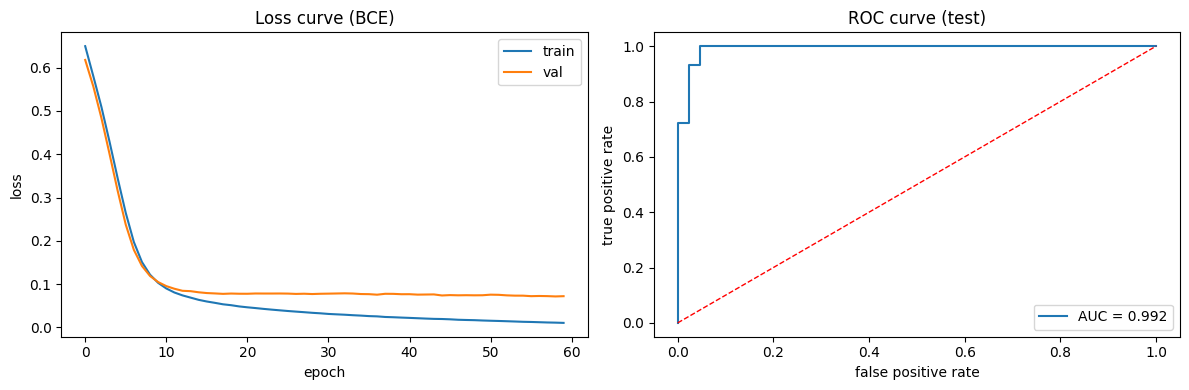

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(clf_history["train"], label="train")
ax[0].plot(clf_history["val"], label="val")
ax[0].set_title("Loss curve (BCE)")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].legend()

fpr, tpr, _ = roc_curve(yc_te, probs)
ax[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
ax[1].plot([0, 1], [0, 1], "r--", lw=1)              # random-guess baseline
ax[1].set_title("ROC curve (test)")
ax[1].set_xlabel("false positive rate"); ax[1].set_ylabel("true positive rate"); ax[1].legend()
plt.tight_layout(); plt.show()

**How to read the ROC curve** — it plots true-positive rate against
false-positive rate as you sweep the decision threshold. A curve bowing toward
the top-left (large area underneath) is good; the red diagonal is random
guessing. The area under it *is* the ROC AUC printed above.

## 4. Recap — your from-scratch checklist

You can now reproduce this for any tabular dataset. The repeatable recipe:

1. **Setup** — seed everything, pick a device.
2. **Split** — train / val / test (stratify for classification).
3. **Scale** — `StandardScaler().fit(X_train)`, transform all sets. (Scale the
   target too for regression; invert it for reporting.)
4. **Tensors + DataLoader** — float32 tensors, mini-batches, shuffle train only.
5. **Model** — MLP; output size & final activation set by the task:
   - regression → 1 unit, no activation
   - binary classification → 1 logit, no activation (sigmoid in the loss)
   - multiclass → `n_classes` logits, `CrossEntropyLoss`
6. **Loss + optimizer** — MSE vs BCE/CE; Adam @ `lr=1e-3` is a safe start.
7. **Train loop** — `zero_grad → forward → loss → backward → step`; `train()` /
   `eval()` + `no_grad()` for validation.
8. **Evaluate on test once** — task-appropriate metrics in original units.
9. **Diagnose** — loss curves (over/under-fit) + a prediction plot.

**Common pitfalls to avoid:** fitting the scaler on all data (leakage), peeking
at test during tuning, forgetting `zero_grad()`, double-applying sigmoid,
reporting metrics in scaled units, and judging an imbalanced classifier by
accuracy alone.

**Next steps to explore:** dropout & weight decay (regularization), early
stopping, learning-rate scheduling, and `k`-fold cross-validation.

See `capstone/capstone_tabular_nn.py` for a self-contained script version of this
whole workflow that you can run from the command line.